In [3]:
# Imports necessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Dict, Optional, List
from dataclasses import dataclass
from collections import deque
import random
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Device configuration (CPU-first)
device = torch.device('cpu')  # GPU optionnel: torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print("\nNote: Ce notebook utilise CPU par defaut pour compatibilite QuantConnect.")

Device: cpu
PyTorch version: 2.10.0+cpu

Note: Ce notebook utilise CPU par defaut pour compatibilite QuantConnect.


In [8]:
# Environnement de Trading complet compatible Gymnasium

class TradingEnvironment:
    """
    Environnement de trading pour RL.

    Features:
    - Observations normalisees (returns, volatility, position)
    - Actions discretes (Hold, Buy, Sell)
    - Rewards bases sur P&L avec penalites
    - Support pour donnees historiques ou simulees
    """

    ACTIONS = {0: 'HOLD', 1: 'BUY', 2: 'SELL'}

    def __init__(
        self,
        prices: Optional[pd.Series] = None,
        initial_cash: float = 10000.0,
        transaction_cost: float = 0.001,  # 0.1%
        lookback: int = 20,
        max_steps: int = 252
    ):
        self.initial_cash = initial_cash
        self.transaction_cost = transaction_cost
        self.lookback = lookback
        self.max_steps = max_steps

        # Use provided prices or generate synthetic
        if prices is not None:
            self.prices = prices.values
        else:
            self.prices = self._generate_synthetic_prices()

        # State dimensions
        self.state_dim = 6  # returns_5d, returns_20d, volatility, position, cash_ratio, unrealized_pnl
        self.action_dim = 3

        self.reset()

    def _generate_synthetic_prices(self, n_days: int = 1000) -> np.ndarray:
        """Generate synthetic price series."""
        np.random.seed(42)
        returns = np.random.normal(0.0003, 0.015, n_days)  # ~7.5% annual return, 24% vol
        prices = 100 * np.exp(np.cumsum(returns))
        return prices

    def _get_observation(self) -> np.ndarray:
        """Compute current observation."""
        idx = self.current_step

        # Returns
        if idx >= 5:
            returns_5d = (self.prices[idx] / self.prices[idx - 5] - 1)
        else:
            returns_5d = 0.0

        if idx >= 20:
            returns_20d = (self.prices[idx] / self.prices[idx - 20] - 1)
            volatility = np.std(np.diff(np.log(self.prices[idx-20:idx+1]))) * np.sqrt(252)
        else:
            returns_20d = 0.0
            volatility = 0.2  # Default 20%

        # Position info
        current_price = self.prices[idx]
        position_value = self.position * current_price
        total_value = self.cash + position_value
        cash_ratio = self.cash / total_value if total_value > 0 else 1.0

        # Unrealized P&L
        if self.position != 0 and self.entry_price > 0:
            unrealized_pnl = (current_price / self.entry_price - 1) * np.sign(self.position)
        else:
            unrealized_pnl = 0.0

        return np.array([
            returns_5d,
            returns_20d,
            volatility / 0.3 - 1,  # Normalize around 30% vol
            self.position,
            cash_ratio * 2 - 1,  # Center around 0
            unrealized_pnl * 10  # Scale up
        ], dtype=np.float32)

    def reset(self, seed: Optional[int] = None) -> np.ndarray:
        """Reset environment."""
        if seed is not None:
            np.random.seed(seed)

        # Random start point
        max_start = len(self.prices) - self.max_steps - self.lookback - 1
        self.start_idx = np.random.randint(self.lookback, max(self.lookback + 1, max_start))
        self.current_step = self.start_idx

        # Portfolio state
        self.cash = self.initial_cash
        self.position = 0  # Number of shares
        self.entry_price = 0.0
        self.trades = 0

        # Tracking
        self.portfolio_values = [self.initial_cash]
        self.rewards_history = []

        return self._get_observation()

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, bool, Dict]:
        """
        Execute action and return (observation, reward, terminated, truncated, info).
        """
        current_price = self.prices[self.current_step]
        old_value = self.cash + self.position * current_price

        # Execute action
        transaction_cost = 0.0

        if action == 1:  # BUY
            if self.position <= 0:
                # Close short position if any
                if self.position < 0:
                    self.cash += self.position * current_price
                    transaction_cost += abs(self.position * current_price) * self.transaction_cost

                # Open long position
                shares = int(self.cash * 0.95 / current_price)  # 95% of cash
                if shares > 0:
                    cost = shares * current_price
                    transaction_cost += cost * self.transaction_cost
                    self.cash -= cost
                    self.position = shares
                    self.entry_price = current_price
                    self.trades += 1

        elif action == 2:  # SELL
            if self.position >= 0:
                # Close long position if any
                if self.position > 0:
                    proceeds = self.position * current_price
                    transaction_cost += proceeds * self.transaction_cost
                    self.cash += proceeds

                # Open short position (simplified: sell 95% worth)
                shares = int(self.cash * 0.95 / current_price)
                if shares > 0:
                    proceeds = shares * current_price
                    transaction_cost += proceeds * self.transaction_cost
                    self.cash += proceeds  # Receive cash from short
                    self.position = -shares
                    self.entry_price = current_price
                    self.trades += 1

        # Deduct transaction costs
        self.cash -= transaction_cost

        # Move to next step
        self.current_step += 1
        new_price = self.prices[self.current_step]

        # Calculate new portfolio value
        new_value = self.cash + self.position * new_price
        self.portfolio_values.append(new_value)

        # Calculate reward
        pnl = new_value - old_value
        reward = pnl / self.initial_cash * 100  # Normalize by initial cash

        # Penalty for excessive trading
        if action != 0:  # If not HOLD
            reward -= 0.01  # Small penalty for trading

        self.rewards_history.append(reward)

        # Check termination
        steps_taken = self.current_step - self.start_idx
        terminated = new_value <= self.initial_cash * 0.5  # Stop if 50% loss
        truncated = steps_taken >= self.max_steps

        info = {
            'portfolio_value': new_value,
            'position': self.position,
            'cash': self.cash,
            'price': new_price,
            'trades': self.trades,
            'pnl': pnl,
            'total_return': (new_value / self.initial_cash - 1) * 100
        }

        return self._get_observation(), reward, terminated, truncated, info

    def get_metrics(self) -> Dict[str, float]:
        """Calculate performance metrics."""
        values = np.array(self.portfolio_values)
        returns = np.diff(values) / values[:-1]

        total_return = (values[-1] / values[0] - 1) * 100
        sharpe = np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252)
        max_dd = np.min(values / np.maximum.accumulate(values) - 1) * 100

        return {
            'total_return': total_return,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_dd,
            'trades': self.trades
        }


# Test environment
env = TradingEnvironment()
state = env.reset(seed=42)

print("Trading Environment cree")
print(f"  State shape: {state.shape}")
print(f"  State: {state}")
print(f"  Actions: {env.ACTIONS}")

# Run random episode
total_reward = 0
for _ in range(100):
    action = np.random.choice([0, 1, 2])
    state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

metrics = env.get_metrics()
print(f"\nRandom Policy Results:")
print(f"  Total Return: {metrics['total_return']:.2f}%")
print(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.2f}")
print(f"  Max Drawdown: {metrics['max_drawdown']:.2f}%")
print(f"  Trades: {metrics['trades']}")

Trading Environment cree
  State shape: (6,)
  State: [ 0.05041772  0.07380994 -0.20452175  0.          1.          0.        ]
  Actions: {0: 'HOLD', 1: 'BUY', 2: 'SELL'}

Random Policy Results:
  Total Return: -30.94%
  Sharpe Ratio: -4.04
  Max Drawdown: -33.53%
  Trades: 23


In [9]:
# Reward Shaping avance

class ShapedRewardCalculator:
    """
    Calcule des rewards shapes pour le trading RL.

    Components:
    1. P&L normalise
    2. Differential Sharpe Ratio
    3. Transaction cost penalty
    4. Drawdown penalty
    5. Trend alignment bonus
    """

    def __init__(
        self,
        pnl_weight: float = 1.0,
        sharpe_weight: float = 0.5,
        transaction_penalty: float = 0.1,
        drawdown_penalty: float = 0.2,
        trend_bonus: float = 0.1,
        lookback: int = 20
    ):
        self.pnl_weight = pnl_weight
        self.sharpe_weight = sharpe_weight
        self.transaction_penalty = transaction_penalty
        self.drawdown_penalty = drawdown_penalty
        self.trend_bonus = trend_bonus
        self.lookback = lookback

        # Tracking for Sharpe
        self.returns_history = []
        self.peak_value = 0.0

    def compute_differential_sharpe(self, new_return: float) -> float:
        """
        Compute incremental Sharpe contribution.
        Based on Moody & Saffell (2001).
        """
        self.returns_history.append(new_return)

        if len(self.returns_history) < self.lookback:
            return 0.0

        recent = self.returns_history[-self.lookback:]
        mean_r = np.mean(recent)
        std_r = np.std(recent) + 1e-8

        # Differential Sharpe approximation
        n = len(recent)
        A = mean_r
        B = np.mean([r**2 for r in recent])

        dS = (B * new_return - 0.5 * A * new_return**2) / ((B - A**2) ** 1.5 + 1e-8)
        return np.clip(dS, -1, 1)  # Clip extreme values

    def compute_drawdown_penalty(self, current_value: float) -> float:
        """Compute drawdown penalty."""
        self.peak_value = max(self.peak_value, current_value)
        drawdown = (self.peak_value - current_value) / self.peak_value

        # Exponential penalty for deeper drawdowns
        if drawdown > 0.05:  # >5% drawdown
            return drawdown ** 2 * 10
        return 0.0

    def compute_trend_alignment(self, position: int, returns_5d: float) -> float:
        """Bonus for position aligned with recent trend."""
        if position > 0 and returns_5d > 0.01:  # Long in uptrend
            return 1.0
        elif position < 0 and returns_5d < -0.01:  # Short in downtrend
            return 1.0
        elif position == 0:  # Flat is neutral
            return 0.0
        else:  # Against the trend
            return -0.5

    def compute_reward(
        self,
        pnl: float,
        portfolio_value: float,
        initial_value: float,
        position: int,
        returns_5d: float,
        traded: bool
    ) -> Tuple[float, Dict[str, float]]:
        """
        Compute shaped reward.

        Returns:
        --------
        tuple : (total_reward, reward_components)
        """
        # Normalize P&L
        pnl_normalized = pnl / initial_value * 100

        # Return for Sharpe
        ret = pnl / (portfolio_value - pnl) if portfolio_value > pnl else 0

        # Components
        components = {
            'pnl': pnl_normalized * self.pnl_weight,
            'sharpe': self.compute_differential_sharpe(ret) * self.sharpe_weight,
            'transaction': -self.transaction_penalty if traded else 0.0,
            'drawdown': -self.compute_drawdown_penalty(portfolio_value) * self.drawdown_penalty,
            'trend': self.compute_trend_alignment(position, returns_5d) * self.trend_bonus
        }

        total_reward = sum(components.values())

        return total_reward, components

    def reset(self):
        """Reset tracking variables."""
        self.returns_history = []
        self.peak_value = 0.0


# Demonstration
reward_calc = ShapedRewardCalculator()

print("Shaped Reward Calculator")
print("="*50)

# Simulate scenarios
scenarios = [
    {'pnl': 50, 'portfolio': 10050, 'position': 1, 'returns': 0.02, 'traded': False},
    {'pnl': -30, 'portfolio': 10020, 'position': 1, 'returns': -0.01, 'traded': False},
    {'pnl': 20, 'portfolio': 10040, 'position': -1, 'returns': -0.02, 'traded': True},
]

for i, s in enumerate(scenarios):
    reward, components = reward_calc.compute_reward(
        pnl=s['pnl'],
        portfolio_value=s['portfolio'],
        initial_value=10000,
        position=s['position'],
        returns_5d=s['returns'],
        traded=s['traded']
    )

    print(f"\nScenario {i+1}: P&L=${s['pnl']}, Position={s['position']}, Traded={s['traded']}")
    print(f"  Components: {', '.join([f'{k}={v:.3f}' for k, v in components.items()])}")
    print(f"  Total Reward: {reward:.3f}")

Shaped Reward Calculator

Scenario 1: P&L=$50, Position=1, Traded=False
  Components: pnl=0.500, sharpe=0.000, transaction=0.000, drawdown=-0.000, trend=0.100
  Total Reward: 0.600

Scenario 2: P&L=$-30, Position=1, Traded=False
  Components: pnl=-0.300, sharpe=0.000, transaction=0.000, drawdown=-0.000, trend=-0.050
  Total Reward: -0.350

Scenario 3: P&L=$20, Position=-1, Traded=True
  Components: pnl=0.200, sharpe=0.000, transaction=-0.100, drawdown=-0.000, trend=0.100
  Total Reward: 0.200


In [11]:
from stable_baselines3 import PPO, DQN

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100000)

Using cpu device


ValueError: The environment is of type <class '__main__.TradingEnvironment'>, not a Gymnasium environment. In this case, we expect OpenAI Gym to be installed and the environment to be an OpenAI Gym environment.

In [12]:
# Training loop complet

def train_agent(
    agent,
    env: TradingEnvironment,
    n_episodes: int = 100,
    max_steps: int = 252,
    update_frequency: int = 20,  # For PPO: update every N steps
    verbose: bool = True
) -> Dict[str, List]:
    """
    Train RL agent on trading environment.

    Parameters:
    -----------
    agent : DQNAgent or PPOAgent
    env : TradingEnvironment
    n_episodes : int
        Number of training episodes
    max_steps : int
        Max steps per episode
    update_frequency : int
        Steps between PPO updates
    verbose : bool
        Print progress

    Returns:
    --------
    dict : Training history
    """
    history = {
        'episode_rewards': [],
        'episode_returns': [],
        'episode_sharpes': [],
        'losses': []
    }

    is_ppo = hasattr(agent, 'store_transition')  # PPO has this method

    for episode in range(n_episodes):
        state = env.reset(seed=episode)
        episode_reward = 0
        step = 0

        while step < max_steps:
            # Select action
            action = agent.select_action(state)

            # Take step
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Store transition
            if is_ppo:
                agent.store_transition(reward, done)
            else:
                agent.buffer.push(state, action, reward, next_state, float(done))

            # Update agent
            if is_ppo:
                if (step + 1) % update_frequency == 0 or done:
                    loss_info = agent.update(next_state)
                    if loss_info:
                        history['losses'].append(loss_info.get('loss', 0))
            else:
                loss = agent.update()
                if loss is not None:
                    history['losses'].append(loss)

            episode_reward += reward
            state = next_state
            step += 1

            if done:
                break

        # Episode metrics
        metrics = env.get_metrics()
        history['episode_rewards'].append(episode_reward)
        history['episode_returns'].append(metrics['total_return'])
        history['episode_sharpes'].append(metrics['sharpe_ratio'])

        if verbose and (episode + 1) % 10 == 0:
            avg_reward = np.mean(history['episode_rewards'][-10:])
            avg_return = np.mean(history['episode_returns'][-10:])
            print(f"Episode {episode+1:3d} | Avg Reward: {avg_reward:7.2f} | "
                  f"Avg Return: {avg_return:6.2f}% | Trades: {metrics['trades']}")

    return history


# Train PPO agent
print("Training PPO Agent")
print("="*60)

# Create fresh environment and agent
train_env = TradingEnvironment(max_steps=252)
ppo_agent =  PPOAgent(state_dim=6, action_dim=3, hidden_dim=64)

# Train (reduced episodes for notebook)
history = train_agent(
    agent=ppo_agent,
    env=train_env,
    n_episodes=50,  # Increase for better results
    max_steps=252,
    update_frequency=64,
    verbose=True
)

Training PPO Agent


NameError: name 'PPOAgent' is not defined

NameError: name 'history' is not defined

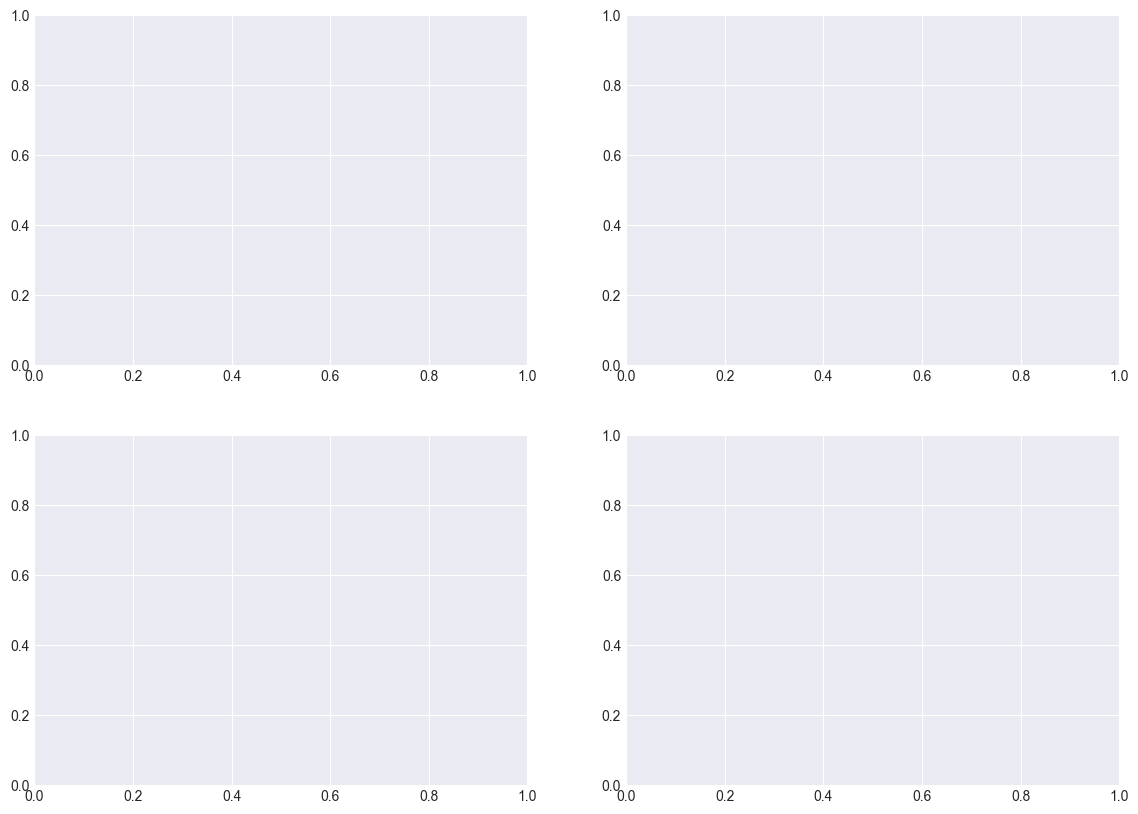

In [13]:
# Visualisation de l'entrainement

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Episode Rewards
ax1 = axes[0, 0]
ax1.plot(history['episode_rewards'], alpha=0.5, label='Episode')
window = 10
if len(history['episode_rewards']) >= window:
    ma = pd.Series(history['episode_rewards']).rolling(window).mean()
    ax1.plot(ma, color='red', linewidth=2, label=f'MA({window})')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Episode Rewards', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Episode Returns
ax2 = axes[0, 1]
ax2.plot(history['episode_returns'], alpha=0.5, label='Episode')
if len(history['episode_returns']) >= window:
    ma = pd.Series(history['episode_returns']).rolling(window).mean()
    ax2.plot(ma, color='red', linewidth=2, label=f'MA({window})')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Return (%)')
ax2.set_title('Episode Returns', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Sharpe Ratios
ax3 = axes[1, 0]
ax3.plot(history['episode_sharpes'], alpha=0.5, label='Episode')
if len(history['episode_sharpes']) >= window:
    ma = pd.Series(history['episode_sharpes']).rolling(window).mean()
    ax3.plot(ma, color='red', linewidth=2, label=f'MA({window})')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax3.set_xlabel('Episode')
ax3.set_ylabel('Sharpe Ratio')
ax3.set_title('Episode Sharpe Ratios', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Training Loss
ax4 = axes[1, 1]
if history['losses']:
    ax4.plot(history['losses'], alpha=0.3)
    if len(history['losses']) >= 100:
        ma = pd.Series(history['losses']).rolling(100).mean()
        ax4.plot(ma, color='red', linewidth=2, label='MA(100)')
    ax4.set_xlabel('Update Step')
    ax4.set_ylabel('Loss')
    ax4.set_title('Training Loss', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nTraining Summary:")
print(f"  Final Avg Return (last 10): {np.mean(history['episode_returns'][-10:]):.2f}%")
print(f"  Final Avg Sharpe (last 10): {np.mean(history['episode_sharpes'][-10:]):.2f}")
print(f"  Best Episode Return: {max(history['episode_returns']):.2f}%")
print(f"  Best Episode Sharpe: {max(history['episode_sharpes']):.2f}")

In [ ]:
# Evaluation de l'agent entraine

def evaluate_agent(
    agent,
    env: TradingEnvironment,
    n_episodes: int = 10
) -> Dict[str, float]:
    """Evaluate trained agent."""
    results = []

    for episode in range(n_episodes):
        state = env.reset(seed=1000 + episode)  # Different seeds from training

        while True:
            action = agent.select_action(state, training=False)
            state, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                break

        metrics = env.get_metrics()
        results.append(metrics)

    # Aggregate results
    return {
        'avg_return': np.mean([r['total_return'] for r in results]),
        'std_return': np.std([r['total_return'] for r in results]),
        'avg_sharpe': np.mean([r['sharpe_ratio'] for r in results]),
        'avg_trades': np.mean([r['trades'] for r in results]),
        'win_rate': sum(1 for r in results if r['total_return'] > 0) / len(results) * 100
    }


# Evaluate PPO
print("Evaluation de l'Agent PPO")
print("="*50)

eval_env = TradingEnvironment(max_steps=252)
eval_results = evaluate_agent(ppo_agent, eval_env, n_episodes=20)

print(f"\nResultats sur 20 episodes de test:")
print(f"  Return moyen: {eval_results['avg_return']:.2f}% (+/- {eval_results['std_return']:.2f}%)")
print(f"  Sharpe moyen: {eval_results['avg_sharpe']:.2f}")
print(f"  Trades moyen: {eval_results['avg_trades']:.1f}")
print(f"  Win Rate: {eval_results['win_rate']:.1f}%")

# Compare with random baseline
print("\nComparaison avec Random Baseline:")

class RandomAgent:
    def __init__(self, action_dim):
        self.action_dim = action_dim
    def select_action(self, state, training=True):
        return np.random.randint(0, self.action_dim)

random_agent = RandomAgent(action_dim=3)
random_results = evaluate_agent(random_agent, eval_env, n_episodes=20)

print(f"  Random Return: {random_results['avg_return']:.2f}%")
print(f"  Random Sharpe: {random_results['avg_sharpe']:.2f}")
print(f"  Improvement: {eval_results['avg_return'] - random_results['avg_return']:.2f}%")

In [13]:
import yfinance as yf
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


In [21]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

data = yf.download(
    tickers,
    start="2018-01-01",
    end="2023-01-01",
    interval="1d"
)


# Séparer prix et volume
price_df = data["Close"]
volume_df = data["Volume"]

print(price_df.head())
print(volume_df.head())

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL       AMZN      GOOGL       MSFT      NVDA
Date                                                            
2018-01-02  40.304169  59.450500  53.220627  78.870346  4.928267
2018-01-03  40.297153  60.209999  54.128632  79.237419  5.252614
2018-01-04  40.484337  60.479500  54.338882  79.934814  5.280303
2018-01-05  40.945263  61.457001  55.059433  80.925865  5.325050
2018-01-08  40.793179  62.343498  55.253826  81.008438  5.488212
Ticker           AAPL      AMZN     GOOGL      MSFT       NVDA
Date                                                          
2018-01-02  102223600  53890000  31766000  22483800  355616000
2018-01-03  118071600  62176000  31318000  26061400  914704000
2018-01-04   89738400  60442000  26052000  21912000  583268000
2018-01-05   94640000  70894000  30250000  23407100  580124000
2018-01-08   82271200  85590000  24644000  22113000  881216000


In [22]:

def prepare_features(price_df: pd.DataFrame, volume_df: pd.DataFrame):
    """
    price_df  : DataFrame index=date, columns=tickers, values=close
    volume_df : DataFrame index=date, columns=tickers, values=volume

    Retourne un DataFrame multi-index colonnes:
    (ticker, feature)
    """
    tickers = list(price_df.columns)

    feats = {}
    for t in tickers:
        px = price_df[t].copy()
        vol = volume_df[t].copy()

        df_t = pd.DataFrame(index=price_df.index)
        df_t["close"] = px
        df_t["ret_1"] = px.pct_change(1)
        df_t["ret_5"] = px.pct_change(5)
        df_t["vol_20"] = px.pct_change().rolling(20).std() * np.sqrt(252)

        vol_mean = vol.rolling(20).mean()
        vol_std = vol.rolling(20).std()
        df_t["vol_z"] = (vol - vol_mean) / (vol_std + 1e-8)

        feats[t] = df_t

    panel = pd.concat(feats, axis=1)
    panel = panel.dropna().copy()
    return panel

In [23]:
class MultiAssetTradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        features_panel,              # DataFrame colonnes multi-index (ticker, feature)
        tickers,
        initial_cash=100000.0,
        transaction_cost=0.001,
        max_steps=252
    ):
        super().__init__()

        self.data = features_panel.copy()
        self.tickers = list(tickers)
        self.n_assets = len(self.tickers)
        self.initial_cash = float(initial_cash)
        self.transaction_cost = float(transaction_cost)
        self.max_steps = int(max_steps)

        # Features par actif
        self.asset_features = ["ret_1", "ret_5", "vol_20", "vol_z"]
        self.n_features_per_asset = len(self.asset_features)

        # Observation = features multi-actifs + poids actuels + cash ratio
        self.obs_dim = self.n_assets * self.n_features_per_asset + self.n_assets + 1

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32
        )

        # Action globale discrète = produit cartésien des actions par actif
        # 0=HOLD, 1=BUY, 2=SELL pour chaque actif
        self.action_space = spaces.Discrete(3 ** self.n_assets)

        self.dates = self.data.index.unique().tolist()
        self._reset_internal_state()

    def _reset_internal_state(self):
        self.current_step = 0
        self.start_step = 0
        self.end_step = min(len(self.dates) - 2, self.max_steps)

        self.cash = self.initial_cash
        self.weights = np.zeros(self.n_assets, dtype=np.float64)
        self.portfolio_value = self.initial_cash
        self.portfolio_values = [self.initial_cash]
        self.n_trades = 0

    def _decode_action(self, action_int):
        # transforme un entier en vecteur base-3 de taille n_assets
        acts = []
        x = int(action_int)
        for _ in range(self.n_assets):
            acts.append(x % 3)
            x //= 3
        return np.array(acts, dtype=np.int64)

    def _get_prices(self, step):
        date = self.dates[step]
        return np.array([self.data.loc[date, (t, "close")] for t in self.tickers], dtype=np.float64)

    def _get_feature_vector(self, step):
        date = self.dates[step]
        feats = []
        for t in self.tickers:
            for f in self.asset_features:
                feats.append(self.data.loc[date, (t, f)])
        feats = np.array(feats, dtype=np.float32)

        cash_ratio = np.array([self.cash / max(self.portfolio_value, 1e-8)], dtype=np.float32)
        weights = self.weights.astype(np.float32)

        obs = np.concatenate([feats, weights, cash_ratio], axis=0)
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_internal_state()
        obs = self._get_feature_vector(self.current_step)
        info = {"portfolio_value": self.portfolio_value}
        return obs, info

    def step(self, action):
        action_vec = self._decode_action(action)

        prices_t = self._get_prices(self.current_step)
        old_value = self.portfolio_value

        # Cible simple : BUY => actif éligible pour poids égal
        # SELL => poids 0
        # HOLD => on garde le poids actuel
        target_weights = self.weights.copy()

        for i, a in enumerate(action_vec):
            if a == 1:      # BUY
                target_weights[i] = 1.0
            elif a == 2:    # SELL
                target_weights[i] = 0.0

        # normalisation en poids égaux parmi les actifs "achetés"
        if target_weights.sum() > 0:
            target_weights = (target_weights > 0).astype(np.float64)
            target_weights /= target_weights.sum()
        else:
            target_weights = np.zeros_like(target_weights)

        turnover = np.abs(target_weights - self.weights).sum()
        trading_cost = turnover * self.transaction_cost * old_value

        # passage au jour suivant
        self.current_step += 1
        prices_tp1 = self._get_prices(self.current_step)

        asset_returns = (prices_tp1 / prices_t) - 1.0
        gross_portfolio_return = np.dot(target_weights, asset_returns)

        new_value = old_value * (1.0 + gross_portfolio_return) - trading_cost
        new_value = max(new_value, 1e-8)

        self.weights = target_weights
        self.portfolio_value = new_value
        self.cash = new_value * (1.0 - self.weights.sum())  # ici souvent 0 si investi
        self.portfolio_values.append(new_value)

        if turnover > 0:
            self.n_trades += 1

        # reward simple
        reward = (new_value - old_value) / old_value

        terminated = bool(new_value <= self.initial_cash * 0.5)
        truncated = bool(self.current_step >= self.end_step)

        obs = self._get_feature_vector(self.current_step)
        info = {
            "portfolio_value": float(new_value),
            "daily_return": float(reward),
            "turnover": float(turnover),
            "n_trades": int(self.n_trades),
            "weights": self.weights.copy()
        }
        return obs, float(reward), terminated, truncated, info

    def get_metrics(self):
        values = np.array(self.portfolio_values, dtype=np.float64)
        rets = pd.Series(values).pct_change().dropna().values

        total_return = values[-1] / values[0] - 1.0
        sharpe = 0.0
        if len(rets) > 1 and np.std(rets) > 1e-12:
            sharpe = (np.mean(rets) / np.std(rets)) * np.sqrt(252)

        running_max = np.maximum.accumulate(values)
        drawdowns = values / running_max - 1.0
        max_drawdown = float(drawdowns.min())

        return {
            "total_return": float(total_return),
            "sharpe": float(sharpe),
            "max_drawdown": max_drawdown,
            "n_trades": int(self.n_trades)
        }

In [24]:
# price_df et volume_df doivent exister avant
panel = prepare_features(price_df[tickers], volume_df[tickers])

env = MultiAssetTradingEnv(
    features_panel=panel,
    tickers=tickers,
    initial_cash=100000,
    transaction_cost=0.001,
    max_steps=252
)


check_env(env, warn=True)
print("Environnement valide pour SB3.")

Environnement valide pour SB3.


In [28]:
def make_env():
    return MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=100000,
        transaction_cost=0.001,
        max_steps=252
    )

train_env = DummyVecEnv([make_env])
train_env = VecMonitor(train_env)

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    verbose=1,
    seed=42
)

model.learn(total_timesteps=200_000)
model.save("ppo_multiasset_discrete")

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | -0.284   |
| time/              |          |
|    fps             | 253      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 252         |
|    ep_rew_mean          | -0.191      |
| time/                   |             |
|    fps                  | 237         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.023576261 |
|    clip_fraction        | 0.272       |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.47       |
|    explained_variance   | -11.9       |
|    learning

In [29]:
def equal_weight_buy_and_hold(price_df, tickers):
    px = price_df[tickers].copy().dropna()
    daily_returns = px.pct_change().dropna()
    ew_returns = daily_returns.mean(axis=1)

    total_return = (1 + ew_returns).prod() - 1
    sharpe = 0.0
    if ew_returns.std() > 1e-12:
        sharpe = ew_returns.mean() / ew_returns.std() * np.sqrt(252)

    equity = (1 + ew_returns).cumprod()
    dd = equity / equity.cummax() - 1
    max_drawdown = dd.min()

    return {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown)
    }

baseline = equal_weight_buy_and_hold(price_df.loc[panel.index], tickers)
print(baseline)

{'total_return': 1.2561200741074838, 'sharpe': 0.6757994460175156, 'max_drawdown': -0.41539158731564996}


In [1]:
def evaluate_trained_model(model, env, deterministic=True):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]
    rewards = []

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated

        rewards.append(reward)
        portfolio_values.append(info["portfolio_value"])

    values = np.array(portfolio_values, dtype=np.float64)
    returns = pd.Series(values).pct_change().dropna()

    total_return = values[-1] / values[0] - 1.0

    sharpe = 0.0
    if returns.std() > 1e-12:
        sharpe = returns.mean() / returns.std() * np.sqrt(252)

    running_max = np.maximum.accumulate(values)
    drawdowns = values / running_max - 1.0
    max_drawdown = drawdowns.min()

    results = {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown),
        "final_portfolio_value": float(values[-1]),
        "avg_reward": float(np.mean(rewards)) if len(rewards) > 0 else 0.0,
        "n_steps": len(rewards),
        "n_trades": info.get("n_trades", None),
        "portfolio_values": values
    }

    return results